In [1]:
import os.path
import sys as sys
from scipy import *
import numpy as np
from numpy import *
from numpy import linalg as LA
from scipy import linalg as LA2
import sympy as sympy
import csv
import time
import matplotlib.pyplot as plt
import itertools as it
from IPython.core.display import HTML
from fractions import Fraction
from copy import deepcopy


sys.path.append('/Users/sashacurcic/SashasDirectory/ANAG/FV_MG/')
from Modules import BasicTools as BT
from Modules import WaveTools as WT
from Modules import PlotTools as PT
from Modules import FFTTools as FFTT
from Modules import OperatorTools as OT
from Modules import GridTransferTools as GTT
from Modules import TestTools as TT
from Modules import SolverTools as ST
from Modules import WaveformTools as WFT

display(HTML("<style>pre { white-space: pre !important; }</style>"))
np.set_printoptions( linewidth = 10000, threshold = 100000)

In [2]:
# Adding comment to test commit.

ceqSwitch = 'c1neqc2'
plotCont = True
IRT = 'IRT'
derivative = False
BooleAve = False
field = 'EB'
WaveFunc1 = WFT.Gauss
WaveFunc2 = WFT.GaussPacket
# appendage = '-' + ceqSwitch + '-' + contSwitch + '-' + IRT

val2 = 0.25

# if (ceqSwitch == 'c1eqc2'):
#     val2 = 1
# else:
#     val2 = 0.25

# if (contSwitch == 'cont'):
#     plotCont = True
# else:
#     plotCont = False

gridBool = True
enlarge = True
fontsize = 14

In [3]:
nh_min = 32
refRatio = 2
CFL = np.sqrt(0.5)
nt = 20
x_0 = 0.
x_1 = 0.5

L = 1.
locs = [x_1]
epsilons = [1, val2]
mus = [1, 1]
k = 13



In [4]:
omegaAMR = BT.Grid(nh_min)
refCells = nh_min // 2
finepart = list((np.arange(refCells) + int((nh_min / 2) - (refCells / 2))))
omegaAMR.AddPatch(refRatio, finepart)
degFreed = omegaAMR.degFreed
nh_max = omegaAMR.nh_max

omegaF = BT.Grid(nh_max)
omegaC = BT.Grid(nh_min)



physicsAMR = BT.PhysProps(omegaAMR, epsilons, mus, locs, L)
cVecAMR = physicsAMR.cVec
cMatAMR = physicsAMR.cMat
csAMR = physicsAMR.cs

physicsC = BT.PhysProps(omegaC, epsilons, mus, locs, L)
cVecC = physicsC.cVec
cMatC = physicsC.cMat
csC = physicsC.cs

physicsF = BT.PhysProps(omegaF, epsilons, mus, locs, L)
cVecF = physicsF.cVec
cMatF = physicsF.cMat
csF = physicsF.cs

cs = csF

In [5]:
t = (0.25 / cs[0]) + (0.25 / cs[1])
sigma, mu = WFT.GaussParams(x_0, x_1, deriv = derivative)
wavesAMR = WT.MakeWaves(omegaAMR)
nullspace = OT.FindNullspace(omegaAMR, wavesAMR)
wavesF = WT.MakeWaves(omegaF)
wavesC = WT.MakeWaves(omegaC)

if (field == 'EB'):
    nullspace = OT.Block(nullspace, var = 2)
    wavesC = OT.Block(wavesC, var = 2)
    wavesF = OT.Block(wavesF, var = 2)
    wavesAMR = OT.Block(wavesAMR, var = 2)
    print('trigger')
# restrictOp = GTT.CoarsenOp(omegaAMR)



trigger


In [6]:
# # For Gaussian:
# waveInitC = WFT.Gauss(omegaC, physicsC, sigma, mu, BooleAve = False, deriv = False, cellAve = True)
# waveInitF = WFT.Gauss(omegaF, physicsF, sigma, mu)
args1 = [sigma, mu]
args2 = [sigma, mu, k]

In [7]:
print('GAUSSIAN:')

wavePropC1 = WFT.WaveEq(omegaC, physicsC, WaveFunc1, args1, t, deriv = derivative, BooleAve = BooleAve, field = field, IRT = IRT)
# wavePropF1 = WFT.WaveEq(omegaF, physicsF, WaveFunc1, args1, t, deriv = derivative, BooleAve = BooleAve, field = field, IRT = IRT)
# wavePropAMR1 = WFT.WaveEq(omegaAMR, physicsAMR, WaveFunc1, args1, t, deriv = derivative, BooleAve = BooleAve, field = field, IRT = IRT)

FCoefsPropC1 = FFTT.FourierCoefs(wavesC, wavePropC1)
# FCoefsPropF1 = FFTT.FourierCoefs(wavesF, wavePropF1)
# FCoefsPropAMR1 = nullspace @ FFTT.FourierCoefs(wavesAMR @ nullspace, wavePropAMR1)


print('\n\n\n\n\n\nGAUSSIAN WAVEPACKET:')

wavePropC2 = WFT.WaveEq(omegaC, physicsC, WaveFunc2, args2, t, deriv = derivative, BooleAve = BooleAve, field = field, IRT = IRT)
# wavePropF2 = WFT.WaveEq(omegaF, physicsF, WaveFunc2, args2, t, deriv = derivative, BooleAve = BooleAve, field = field, IRT = IRT)
# wavePropAMR2 = WFT.WaveEq(omegaAMR, physicsAMR, WaveFunc2, args2, t, deriv = derivative, BooleAve = BooleAve, field = field, IRT = IRT)

FCoefsPropC2 = FFTT.FourierCoefs(wavesC, wavePropC2)
# FCoefsPropF2 = FFTT.FourierCoefs(wavesF, wavePropF2)
# FCoefsPropAMR2 = FFTT.FourierCoefs(wavesAMR @ nullspace, wavePropAMR2)


GAUSSIAN:

ADVECTION:
ShiftX: True
TRIGGER 1!

fresh out:
[-0.375    -0.34375  -0.3125   -0.28125  -0.25     -0.21875  -0.1875   -0.15625  -0.125    -0.09375  -0.0625   -0.03125   0.        0.03125   0.0625    0.09375   0.125     0.140625  0.15625   0.171875  0.1875    0.203125  0.21875   0.234375  0.25      0.265625  0.28125   0.296875  0.3125    0.328125  0.34375   0.359375  0.375   ]


YOU ARE RUNNING GAUSS! False


REFLECTION:
REFLECT:
ShiftX: False
TRIGGER 2

fresh out:
[ 0.625    0.59375  0.5625   0.53125  0.5      0.46875  0.4375   0.40625  0.375    0.34375  0.3125   0.28125  0.25     0.21875  0.1875   0.15625  0.125    0.09375  0.0625   0.03125  0.      -0.03125 -0.0625  -0.09375 -0.125   -0.15625 -0.1875  -0.21875 -0.25    -0.28125 -0.3125  -0.34375 -0.375  ]


YOU ARE RUNNING GAUSS! False

[ 0.625    0.59375  0.5625   0.53125  0.5      0.46875  0.4375   0.40625  0.375    0.34375  0.3125   0.28125  0.25     0.21875  0.1875   0.15625  0.125    0.09375  0.0625   0.03125  0.     

GAUSSIAN:
GAUSSIAN WAVEPACKET:


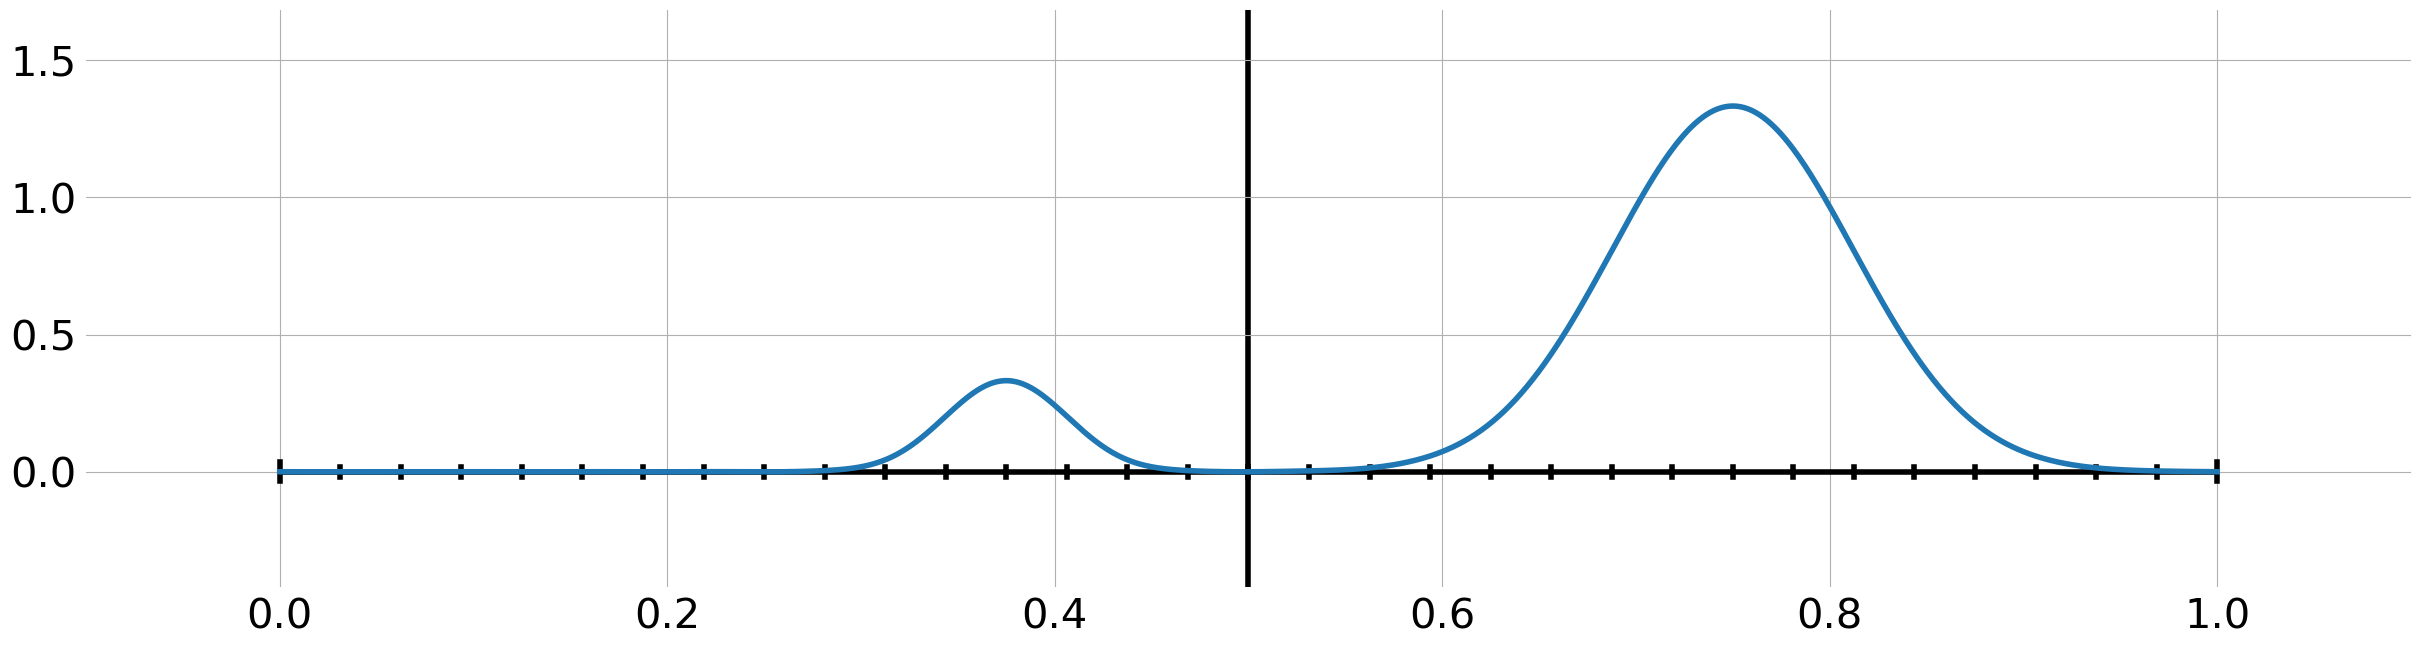

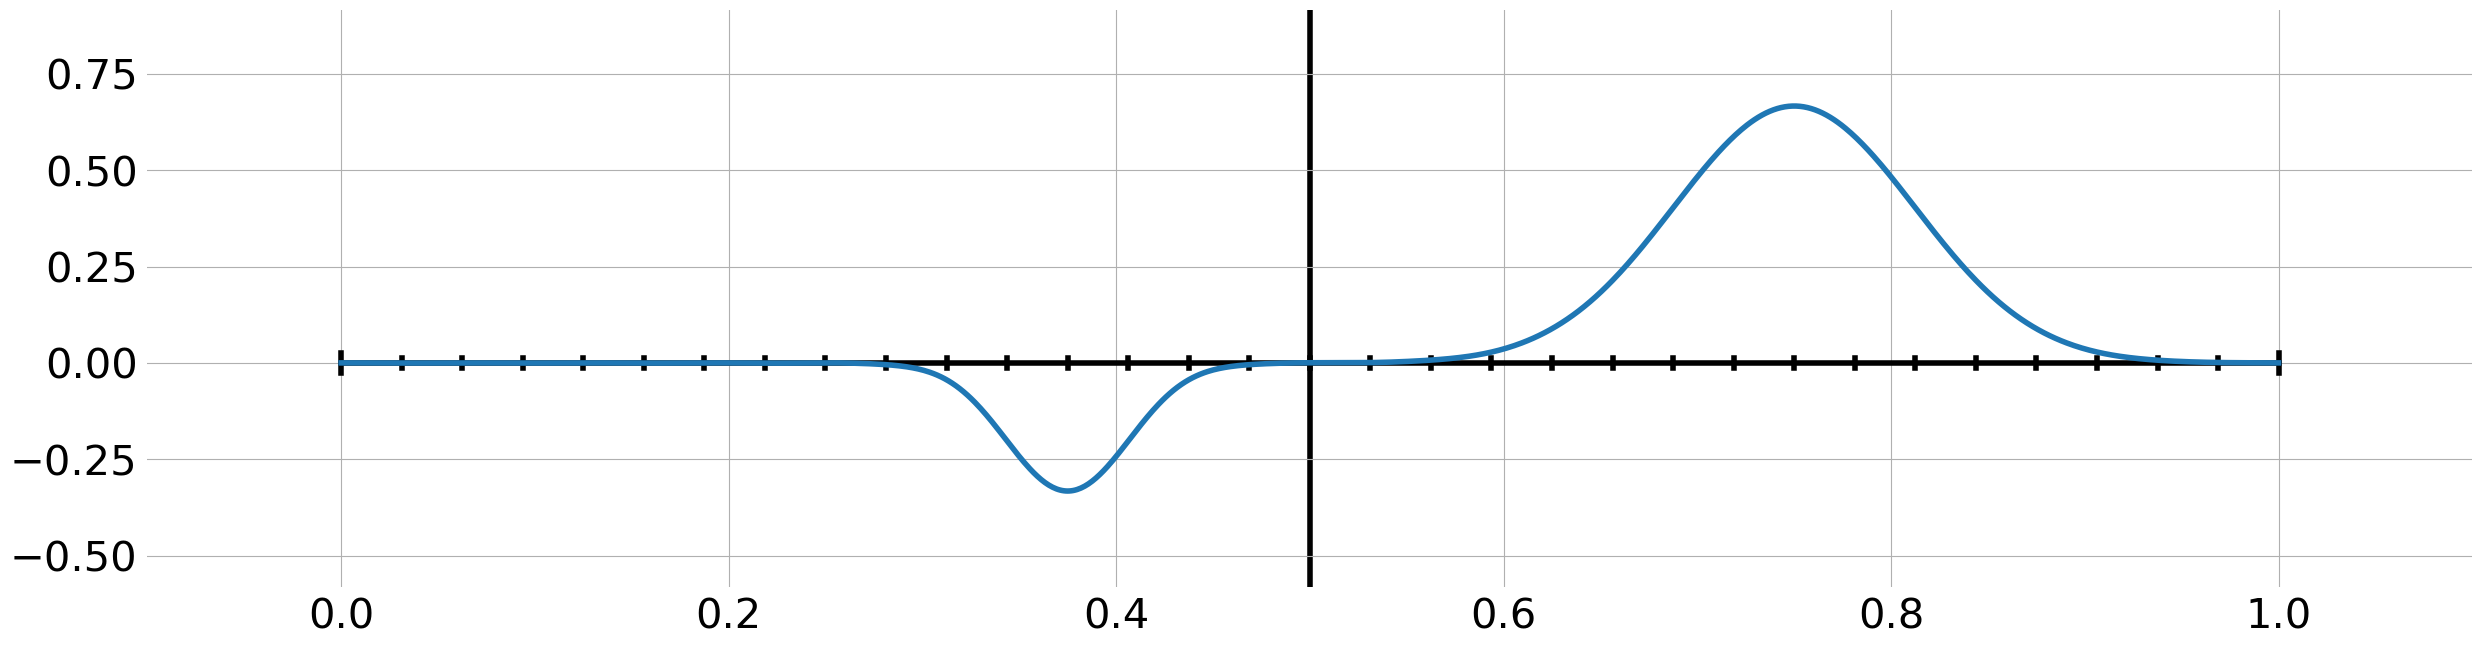

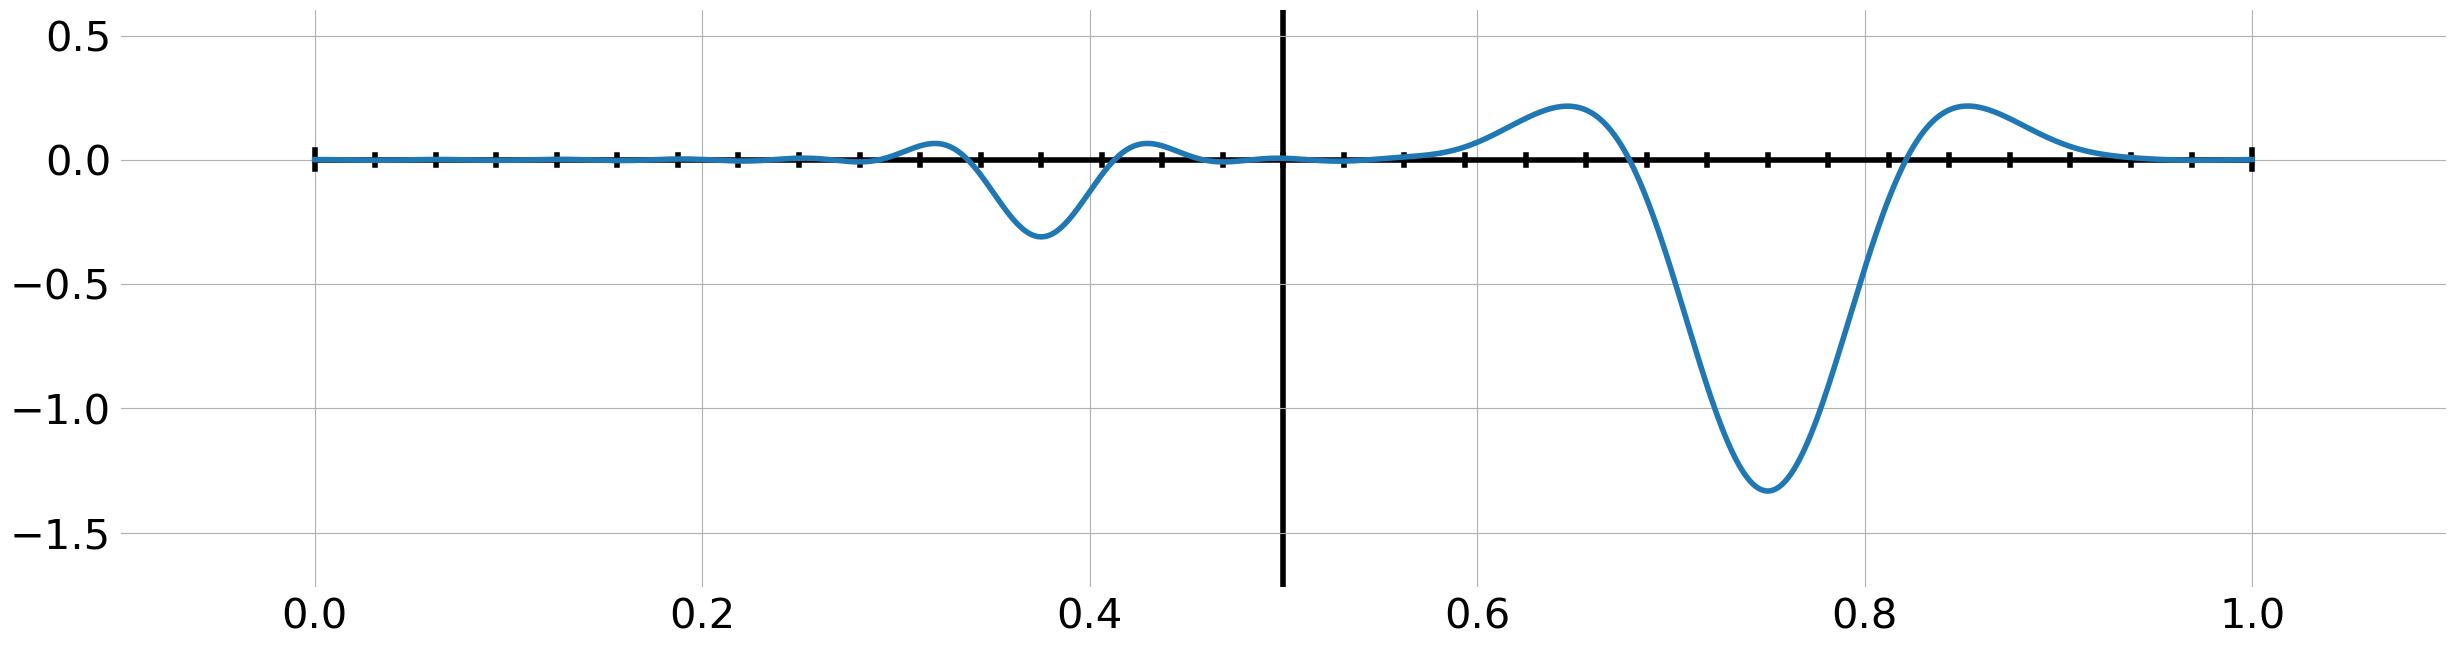

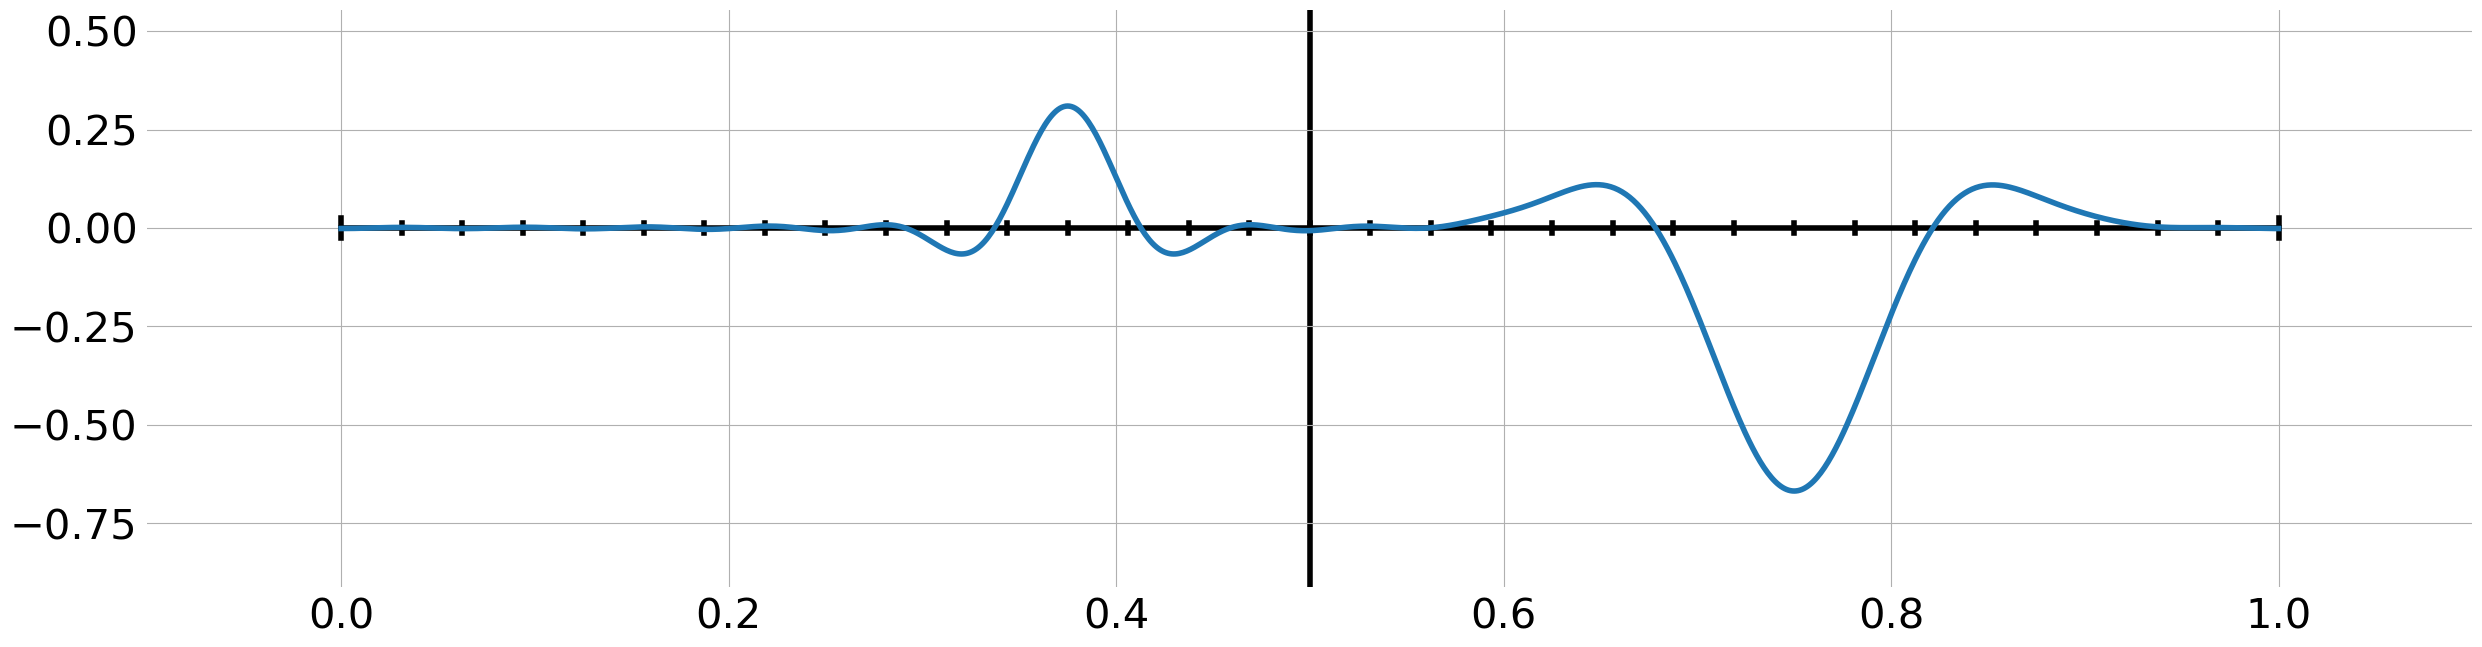

In [8]:
print('GAUSSIAN:')

PT.PlotMixedWave(omegaC, physicsC, waves = [], FCoefs = FCoefsPropC1, rescale = [6, 3], xGrid = gridBool, yGrid = gridBool, plotCont = plotCont, enlarge = enlarge)
# PT.PlotMixedWave(omegaF, physicsF, waves = [], FCoefs = FCoefsPropF1, rescale = [6, 3], xGrid = gridBool, yGrid = gridBool, plotCont = plotCont, enlarge = enlarge)
# PT.PlotMixedWave(omegaAMR, physicsAMR, waves = [], FCoefs = FCoefsPropAMR1, rescale = [6, 3], xGrid = gridBool, yGrid = gridBool, plotCont = plotCont, enlarge = enlarge)


print('GAUSSIAN WAVEPACKET:')

PT.PlotMixedWave(omegaC, physicsC, waves = [], FCoefs = FCoefsPropC2, rescale = [6, 3], xGrid = gridBool, yGrid = gridBool, plotCont = plotCont, enlarge = enlarge)
# PT.PlotMixedWave(omegaF, physicsF, waves = [], FCoefs = FCoefsPropF2, rescale = [6, 3], xGrid = gridBool, yGrid = gridBool, plotCont = plotCont, enlarge = enlarge)
# PT.PlotMixedWave(omegaAMR, physicsAMR, waves = [], FCoefs = FCoefsPropAMR2, rescale = [6, 3], xGrid = gridBool, yGrid = gridBool, plotCont = plotCont, enlarge = enlarge)
